In [1]:
import numpy as np
import pandas as pd
import random
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, fbeta_score, log_loss, confusion_matrix 
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
from skmultilearn.problem_transform import LabelPowerset
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.model_selection import GridSearchCV
from sklearn.impute import KNNImputer
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.metrics import hamming_loss
from sklearn.metrics import classification_report
from itertools import product
import statsmodels.api as sm

import sys
import math
import shap
import xgboost as xgb

sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import read_data, convert_multiple_cases, encode_cyclical, optimal_threashold_fbeta_scalar, plot_imbalance, dataframe_describe

import warnings
warnings.filterwarnings("ignore")

NUTS0 = 'GR'
P = 'P1'
p = P.lower()

# file1 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\CMacedonia\GR_CMacedonia_WNV_Dataset_OP_2010_2023.csv'
file2 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\Thessaly\GR_Thessaly_WNV_Dataset_OP_2010_2023.csv'
# file3 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\Thrace\GR_Thrace_WNV_Dataset_OP_2010_2023.csv'
# file4 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\Attica\GR_Attica_WNV_Dataset_OP_2010_2023.csv'

# dataset1 = read_data(file1)
dataset2 = read_data(file2)
# dataset3 = read_data(file3)
# dataset4 = read_data(file4)


# dataset1.head()

dataset2.head()

# dataset3.head()

# dataset4.head()

# dataset = pd.concat([dataset1, dataset2, dataset3, dataset4])
dataset = dataset2

dataset.reset_index(drop = True, inplace = True)

print(dataset.shape)

(504, 112)


In [2]:
dataset.head()

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases
0,EL611,2010,1,21.720538,39.507246,0.344330,0.131772,-0.164562,-0.131772,0.351663,0.138953,-0.161584,-0.138953,0.072157,0.073429,0.095126,0.073429,10.324867,4.699393,7.541364,13.255044,13.255044,3.412974,1.761039,0.200398,1.498356,1.498356,6.868921,3.230216,3.870881,7.395288,7.395288,1.743648,14.674717,9.513972,36.701100,124.217848,292.411665,2058.948979,738.424528,23.820146,14.958333,20.083333,37.893082,917.372318,41.0,-12.0,53.0,5.666667,25.166667,25.833333,3.833333,2052.0,406.0,45.0,69.435433,971.0,166.0,200.0,839.0,31,36,30,12,12,1,6,7,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.0,1.0,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,17466.0,77268.0,28083.0,122817.0,17105.0,74553.0,35419.0,127077.0,3296.18,10352.0,10375.0,0
1,EL612,2010,1,22.407574,39.702044,0.263468,-0.034510,-0.273834,0.034510,0.249646,-0.036767,-0.264302,0.036767,0.058782,0.058005,0.042991,0.058005,12.333341,6.793895,10.575814,16.242166,16.242166,4.519342,1.699212,0.966283,2.243861,2.243861,8.426342,4.246554,5.771048,9.243013,9.243013,2.268996,16.713441,9.078019,35.835411,107.246464,280.483500,1454.989694,769.064516,24.808533,17.250000,22.166667,45.238095,931.640781,45.0,-4.0,49.0,8.333333,28.833333,28.833333,6.333333,1448.0,281.0,37.0,67.310943,640.0,170.0,170.0,594.0,31,36,30,12,12,1,6,7,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.0,1.0,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,23291.0,94577.0,25594.0,143462.0,22117.0,93495.0,30638.0,146250.0,5066.81,7604.0,8362.0,0
2,EL613,2010,1,22.862978,39.279998,0.322976,0.136636,-0.129853,-0.136636,0.309199,0.148988,-0.100460,-0.148988,0.043004,0.048798,0.061535,0.048798,12.159471,6.264925,9.527607,14.859624,14.859624,6.342837,2.651805,1.864013,3.901596,3.901596,9.251154,4.458365,5.695810,9.380610,9.380610,3.658866,16.772062,9.868127,44.910923,82.850549,304.801321,1435.288760,517.865979,16.705354,16.833333,19.500000,44.318182,847.277279,42.0,-2.0,44.0,9.000000,27.500000,27.500000,7.166667,1428.0,305.0,22.0,74.352423,644.0,122.0,122.0,473.0,31,20,30,12,12,1,6,1,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,493.305640,59.481798,0

In [3]:
dataset = encode_cyclical(dataset, 'month', 12)

In [4]:
dataset.cases.sum()

210

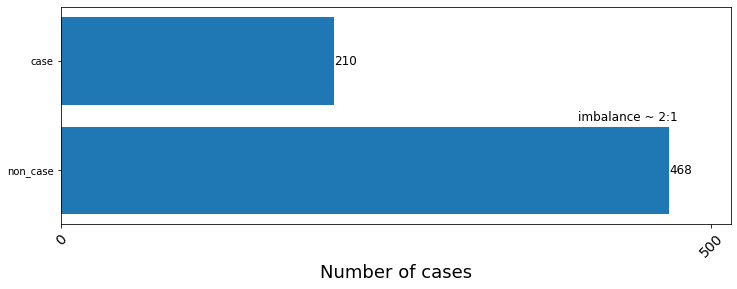

In [5]:
plot_imbalance(dataset, target_column='cases')

In [6]:
#dataset = dataset.query('month >= 5 & month <= 11')
dataset = dataset.query('month >= 5')
dataset.reset_index(drop=True, inplace=True)

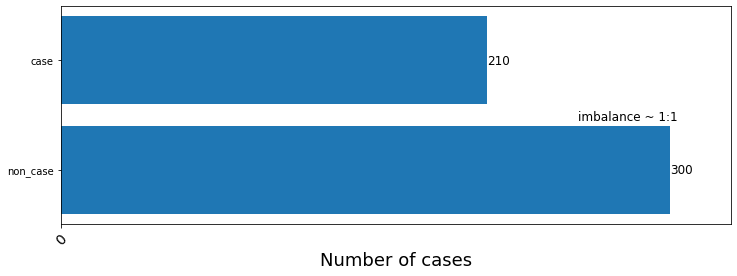

In [7]:
plot_imbalance(dataset, target_column='cases')

In [8]:
dataset.shape

(336, 114)

In [9]:
dataset.cases.sum()

210

In [10]:
dsc = dataframe_describe(dataset, target_column = 'cases')
dsc.head(15)

,year,non-case,case,total,0/1 ratio
0,2010,21,9,30,2.33%
1,2011,17,30,47,0.57%
2,2012,24,0,24,inf%
3,2013,24,0,24,inf%
4,2014,24,0,24,inf%
5,2015,24,0,24,inf%
6,2016,24,0,24,inf%
7,2017,24,0,24,inf%
8,2018,22,7,29,3.14%
9,2019,18,53,71,0.34%


In [11]:
X = dataset.select_dtypes(exclude=['object']).drop(columns=['cases'])
y = dataset['cases']

In [12]:
n_folds = 10
k_fold = StratifiedKFold(n_splits = n_folds, shuffle = True, random_state = 0)
#k_fold = KFold(n_splits = n_folds, shuffle = True, random_state = 0)

In [58]:
features_to_remove = ['bio16', 'lst_mean', 'month_cos', 'slope_mean_1km_max',
       'distance_to_river_max', 'aspect_mean_200m_max',
       'elevation_mean_1km_std', 'elevation_mean_1km_max',
       'hillshade_mean_1km_max', 'fs_area_1km_max', 'flow_accu_200m_max',
       'distance_to_coast_max', 'distance_to_coast_std', 'flow_accu_200m_min',
       'distance_to_river_std', 'slope_mean_1km_std', 'fs_area_1km_min',
       'aspect_mean_200m_std', 'flow_accu_200m_std', 'hillshade_mean_1km_std',
       'fs_area_1km_std', 'elevation_mean_1km_min', 'males_lt15', 'ndbi_std',
       'ndbi_mean', 'males_total', 'females_lt15', 'females_15t64',
       'ndwi_mean', 'females_total', 'ndvi_mean', 'unl_total', 'ndbi',
       'hillshade_mean_1km_min', 'lst_apr_mean', 'aspect_mean_200m_min',
       'lc_prop3', 'lst_feb_mean', 'bio2', 'bio5', 'bio6', 'bio7', 'bio8',
       'lst_mar_night_mean', 'bio12', 'lst_jan_night_mean', 'lst_apr_day_mean',
       'lst_mar_day_mean', 'bio17', 'ndmi', 'lc_prop1', 'lc_type1',
       'slope_mean_1km_min', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5',
       'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'lst_mar_mean',
       'distance_to_river_min', 'distance_to_coast_min', 'bio3', 'l_total']


features_to_remove = features_to_remove + ['x', 'y', 'year', 'month']
feature_names = X.select_dtypes(exclude=['object']).drop(columns = features_to_remove).columns
print(feature_names.to_list())

['ndvi', 'ndwi', 'ndmi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_night_mean', 'lst_feb_night_mean', 'lst_apr_night_mean', 'lst_jan_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'mosq_pred_acc', 'mosq_pred_mean', 'bio1', 'bio4', 'bio9', 'bio10', 'bio11', 'bio13', 'bio14', 'bio15', 'bio18', 'bio19', 'lc_prop2', 'males_15t64', 'males_gt65', 'females_gt65', 'mio_eur', 'month_sin']


In [59]:
print(f"Total Features Used: {len(feature_names)}")

Total Features Used: 38


In [60]:
fold_counter = 0
y_train_list = []
y_test_list = []
y_train_prob_list = []
y_test_prob_list = []

for train_idx, test_idx in k_fold.split(X, y):
    print(f'Fold: {fold_counter+1}/{n_folds}')

    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]

    data_train = convert_multiple_cases(data_train, target_col='cases')
    #data_train['cases'] = data_train['cases'].apply(lambda x: 1 if x > 0 else 0)
    data_test['cases'] = data_test['cases'].apply(lambda x: 1 if x > 0 else 0)

    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)

    sum_negatives = data_train['cases'].value_counts().get(0)
    sum_positives = data_train['cases'].value_counts().get(1)

    params = {
        "objective": "binary:logistic",
        "device": "gpu", 
        "eval_metric": "logloss",
        "learning_rate": 0.1,
        "min_split_loss": 0.5,
        "max_depth": 3, 
        "reg_alpha": 0.5,
        "reg_lambda": 0.5,
        "min_child_weight": 1.5,
        "scale_pos_weight": sum_negatives/sum_positives, 
    }


    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])

    y_train = data_train['cases']
    y_test = data_test['cases']

    print(f"Training set 0/1 Ratio: {(data_train['cases'].value_counts().get(0) / data_train['cases'].value_counts().get(1)):.2f}")
    print(f"Test set 0/1 Ratio: {(data_test['cases'].value_counts().get(0) / data_test['cases'].value_counts().get(1)):.2f}")
    print(f"Weight: {(sum_negatives/sum_positives):.2f}")
    
    scaler = MinMaxScaler(feature_range = (-1, 1))
    #scaler = RobustScaler()
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
            
    imputer = KNNImputer()
    imputer.fit(X_train)
    X_train_imputed = imputer.transform(X_train_scaled)
    X_test_imputed = imputer.transform(X_test_scaled)

    model = xgb.XGBClassifier(**params)   
    trained_model = model.fit(X_train_imputed, y_train)

    y_train_prob = trained_model.predict_proba(X_train_imputed)
    y_test_prob = trained_model.predict_proba(X_test_imputed)

    y_train_list.append(y_train)
    y_test_list.append(y_test)
    y_train_prob_list.append(y_train_prob)
    y_test_prob_list.append(y_test_prob)
    fold_counter += 1

Fold: 1/10
Training set 0/1 Ratio: 1.40
Test set 0/1 Ratio: 7.50
Weight: 1.40
Fold: 2/10
Training set 0/1 Ratio: 1.40
Test set 0/1 Ratio: 7.50
Weight: 1.40
Fold: 3/10
Training set 0/1 Ratio: 1.53
Test set 0/1 Ratio: 7.50
Weight: 1.53
Fold: 4/10
Training set 0/1 Ratio: 1.48
Test set 0/1 Ratio: 7.50
Weight: 1.48
Fold: 5/10
Training set 0/1 Ratio: 1.42
Test set 0/1 Ratio: 7.50
Weight: 1.42
Fold: 6/10
Training set 0/1 Ratio: 1.41
Test set 0/1 Ratio: 7.50
Weight: 1.41
Fold: 7/10
Training set 0/1 Ratio: 1.33
Test set 0/1 Ratio: 10.00
Weight: 1.33
Fold: 8/10
Training set 0/1 Ratio: 1.36
Test set 0/1 Ratio: 10.00
Weight: 1.36
Fold: 9/10
Training set 0/1 Ratio: 1.48
Test set 0/1 Ratio: 10.00
Weight: 1.48
Fold: 10/10
Training set 0/1 Ratio: 1.50
Test set 0/1 Ratio: 10.00
Weight: 1.50


In [61]:
y_train_true = np.concatenate(y_train_list, axis=0)
y_test_true = np.concatenate(y_test_list, axis=0)

y_train_proba = np.concatenate(y_train_prob_list, axis = 0)
y_test_proba = np.concatenate(y_test_prob_list, axis = 0)

In [62]:
train_loss = log_loss(y_train_true, y_train_proba[:, 1])
print(f"Train Logloss: {train_loss:.4f}")

test_loss = log_loss(y_test_true, y_test_proba[:, 1])
print(f"Test Loss: {test_loss:.4f}")

Train Logloss: 0.0357
Test Loss: 0.1687


In [63]:
classification_thresholds = optimal_threashold_fbeta_scalar(y_train_proba[:,1], y_train_true, beta = 2, round_factor = 2)
print(classification_thresholds)

0.46


In [64]:
thr = classification_thresholds

In [65]:
y_train_pred = np.where(y_train_proba[:,1] > thr, 1, 0)
y_test_pred = np.where(y_test_proba[:,1] > thr, 1, 0)

In [66]:
print(classification_report(y_test_true, y_test_pred, output_dict=False))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       300
           1       0.65      0.67      0.66        36

    accuracy                           0.93       336
   macro avg       0.80      0.81      0.81       336
weighted avg       0.93      0.93      0.93       336



In [67]:
'''
MCM = [[TN, FP],
       [FN, TP]]
'''


cm = confusion_matrix(y_test_true, y_test_pred)

print(cm)

[[287  13]
 [ 12  24]]


In [68]:
data_train_shap = dataset.copy()
#data_train_shap = convert_multiple_cases(data_train_shap, target_col='cases')
data_train_shap['cases'] = data_train_shap['cases'].apply(lambda x: 1 if x > 0 else 0)

X_train = data_train_shap.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
y_train = data_train_shap['cases']

sum_negatives = data_train_shap['cases'].value_counts().get(0)
sum_positives = data_train_shap['cases'].value_counts().get(1)

scaler = MinMaxScaler(feature_range = (-1, 1))
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
            
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns)


In [69]:
# Tree explainer

# curently not working with multioutput models

params["scale_pos_weight"] = sum_negatives/sum_positives

model = xgb.XGBClassifier(**params)   
trained_model = model.fit(X_train_imputed, y_train)

tree_explainer = shap.TreeExplainer(model)
#tree_shap_values = tree_explainer.shap_values(X_train_imputed)
tree_shap_values = tree_explainer(X_train_imputed)

In [70]:
# shap_values_path = r'E:\Drive\NOA\MBD-Prediction\JRC Interpretability\Greece\data\ValuesShap\GR_OP_2010-2023_Tree_Shapely_Values.npz'

# np.savez(shap_values_path, *tree_shap_values)

# # shap_values = []
# # loaded_shap_values = np.load(shap_values_path)

# # for key in loaded_shap_values.keys():
# #     shap_values.append(loaded_shap_values[key])

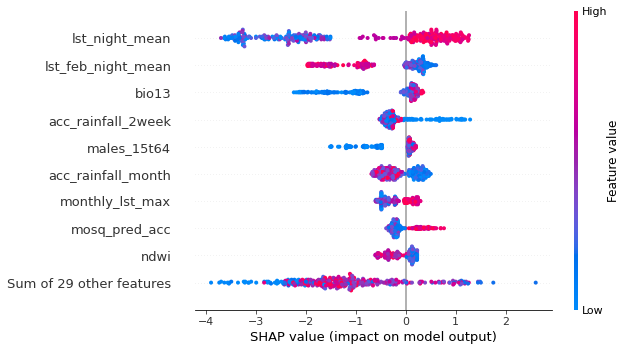

In [71]:
shap.plots.beeswarm(shap_values = tree_shap_values, max_display=10)

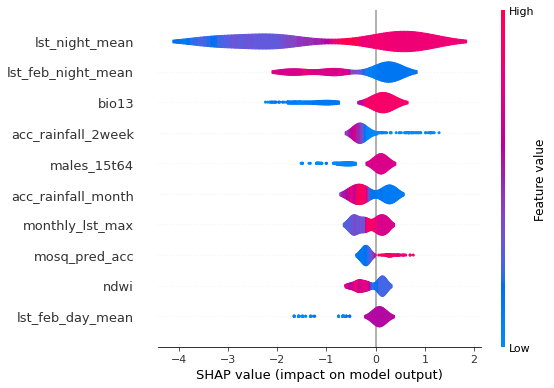

In [72]:
shap.summary_plot(tree_shap_values, feature_names = X_train.columns, features = X_train_imputed, plot_type='violin', max_display=10)

In [73]:
shap_lim = (-4, 2)

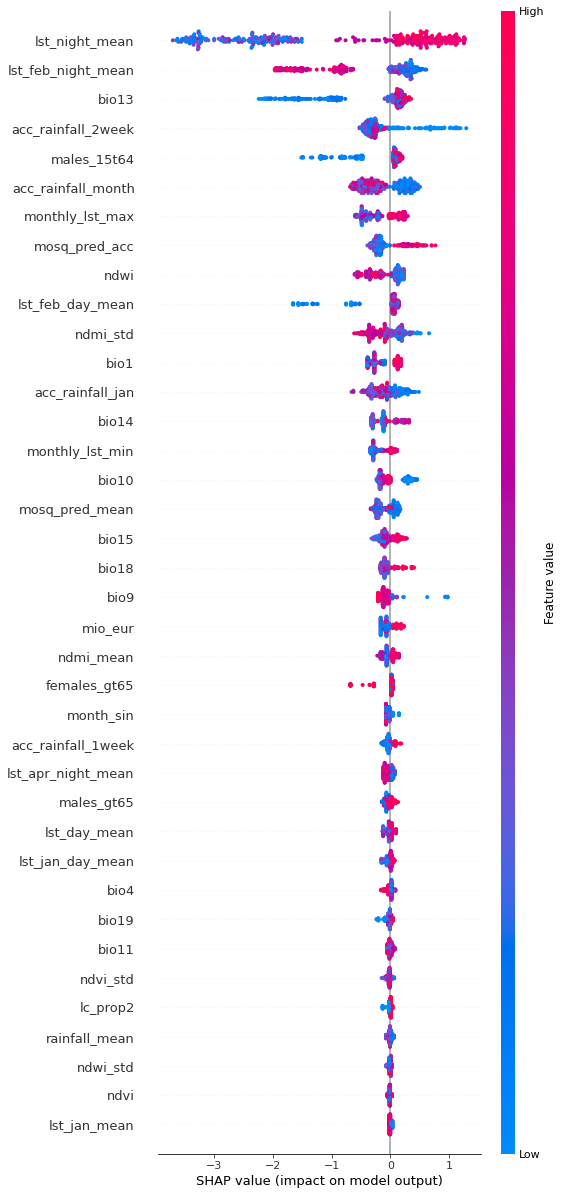

In [74]:
shap.summary_plot(tree_shap_values.values, feature_names = X_train.columns, features = tree_shap_values.data, max_display=110)

In [75]:
#sorted_mean_abs_values_idx[-68:-1]

In [76]:
location_columns = data_train_shap.iloc[:, :5]
wnv_columns = data_train_shap['cases']

In [77]:
tree_shap_values_df = pd.DataFrame(tree_shap_values.values, columns=X_train.columns)
tree_shap_values_df = pd.concat([location_columns, tree_shap_values_df, wnv_columns], axis=1)

In [78]:
X_train

,ndvi,ndwi,ndmi_mean,ndvi_std,ndmi_std,ndwi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_night_mean,lst_feb_night_mean,lst_apr_night_mean,lst_jan_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio4,bio9,bio10,bio11,bio13,bio14,bio15,bio18,bio19,lc_prop2,males_15t64,males_gt65,females_gt65,mio_eur,month_sin
0,0.432134,-0.229216,0.180758,0.055951,0.061871,0.050074,20.573273,6.392794,7.946604,7.467222,1.323154,7.467222,4.015722,4.775597,25.891887,2.126777,5.886608,46.019261,63.803317,740.965698,395.050314,13.168344,14.958333,917.372318,25.166667,25.833333,3.833333,406.0,45.0,69.435433,200.0,839.0,36,77268.0,28083.0,35419.0,3296.18,5.000000e-01
1,0.475058,-0.267080,0.189206,0.059974,0.070868,0.041458,22.445716,10.166321,11.080809,7.947266,2.673213,7.947266,6.060683,5.058817,27.512867,1.612836,6.329721,37.885570,48.385072,467.452113,358.860215,11.962007,17.250000,931.640781,28.833333,28.833333,6.333333,281.0,37.0,67.310943,170.0,594.0,36,94577.0,25594.0,30638.0,5066.81,5.000000e-01
2,0.459280,-0.232124,0.199480,0.045745,0.047301,0.035917,21.148234,10.010106,11.320285,8.364928,3.970343,8.364928,6.647975,6.030619,26.828763,1.052443,10.108034,24.252836,31.573303,450.450030,362.762887,12.092096,16.833333,847.277279,27.500000,27.500000,7.166667,305.0,22.0,74.352423,122.0,473.0,20,67953.0,17481.0,22660.0,3451.36,5.000000e-01
3,0.507097,-0.305583,0.188706,0.061161,0.060312,0.038624,27.894212,6.392794,7.946604,12.816918,1.323154,4.642530,4.015722,9.594780,31.904465,4.145616,7.868992,55.475135,128.489617,869.479792,334.103774,10.777541,14.958333,917.372318,25.166667,25.833333,3.833333,406.0,45.0,69.435433,200.0,839.0,36,77268.0,28083.0,35419.0,3296.18,1.224647e-16
4,0.466598,-0.326896,0.141956,0.065013,0.073713,0.039188,30.183121,10.166321,11.080809,13.274562,2.673213,5.028989,6.060683,10.633728,36.232652,3.829831,7.836852,67.735168,118.709463,586.176867,323.921147,10.449069,17.250000,931.640781,28.833333,28.833333,6.333333,281.0,37.0,67.310943,170.0,594.0,36,94577.0,25594.0,30638.0,5066.81,1.224647e-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
331,0.395957,-0.342487,0.061840,0.058855,0.062384,0.043219,23.101310,10.128541,11.575010,13.831276,1.280138,5.371649,6.282411,12.085556,26.411290,2.193273,53.378182,56.226727,67.948682,1413.436991,1532.602151,49.438779,17.375000,883.979895,13.666667,28.333333,6.333333,225.0,17.0,75.887306,490.0,308.0,36,83984.0,28103.0,34457.0,3864.93,-5.000000e-01
332,0.437129,-0.358060,0.165735,0.054706,0.056947,0.042009,22.303934,10.855230,10.375943,15.016245,3.083387,6.281480,7.417859,12.553918,24.313299,1.429600,33.749925,36.572321,44.317612,2028.434886,448.577320,14.470236,17.000000,810.443201,13.500000,27.166667,7.000000,212.0,11.0,65.332583,340.0,323.0,20,59802.0,19825.0,24965.0,2354.66,-5.000000e-01
333,0.453092,-0.365768,0.171253,0.065036,0.065742,0.059087,13.802113,8.442297,9.960925,7.533686,1.196473,5.066013,5.219991,0.027736,19.763396,6.714799,36.913466,75.394665,201.443977,2079.452450,928.223270,30.940776,15.541667,812.252293,12.000000,25.500000,5.333333,222.0,26.0,69.891418,405.0,253.0,36,68346.0,30036.0,35332.0,2452.45,-2.449294e-16
334,0.405276,-0.342445,0.093609,0.066684,0.068386,0.054830,15.925625,10.128541,11.575010,8.003692,1.280138,5.371649,6.282411,-0.090358,22.202832,3.964168,20.721338,38.641634,118.925035,1532.362026,1636.046595,54.534886,17.375000,883.979895,13.666667,28.333333,6.333333,225.0,17.0,75.887306,490.0,308.0,36,83984.0,28103.0,34457.0,3864.93,-2.449294e-16


In [79]:
tree_shap_values_df

,NUTS3_ID,year,month,x,y,ndvi,ndwi,ndmi_mean,ndvi_std,ndmi_std,ndwi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_night_mean,lst_feb_night_mean,lst_apr_night_mean,lst_jan_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio4,bio9,bio10,bio11,bio13,bio14,bio15,bio18,bio19,lc_prop2,males_15t64,males_gt65,females_gt65,mio_eur,month_sin,cases
0,EL611,2010,5,21.720538,39.507246,-0.009893,-0.388268,0.086162,-0.013351,0.167109,0.004058,-0.026625,-0.118927,-0.752856,-2.354691,0.289123,-0.096808,-0.005356,-0.300701,-0.344292,0.014174,-0.102656,-0.405106,0.247749,-0.273157,-0.166230,0.150937,-0.273999,-0.025326,-0.117443,-0.182690,-0.017910,0.139044,-0.111418,-0.084104,-0.044719,0.040100,0.006012,0.040758,-0.028599,0.016668,-0.058127,-0.020226,0
1,EL612,2010,5,22.407574,39.702044,-0.009893,-0.538599,0.034897,0.014585,-0.374242,-0.013816,-0.026625,0.043753,0.069224,-3.604008,0.082042,-0.058789,-0.005356,-0.341930,-0.494448,0.014174,-0.042695,-0.415836,0.407858,0.257688,-0.148801,0.150937,0.073327,-0.025326,-0.143597,-0.033965,0.026719,0.129322,0.122081,-0.000122,-0.044719,0.040100,0.006012,0.080742,-0.028599,0.016668,0.096395,-0.020226,0
2,EL613,2010,5,22.862978,39.279998,-0.009893,-0.495414,0.046136,0.009278,0.336892,-0.013816,-0.058143,0.016157,0.040064,-2.300112,-0.761222,-0.097023,-0.005356,-0.259882,-0.488576,0.006366,-0.050860,-0.349855,0.315743,0.204932,-0.157897,0.109617,-0.273999,0.018944,-0.135748,-0.182690,-0.016380,0.109979,0.079491,0.050296,-0.044719,-0.037498,-0.025059,-0.598787,-0.025089,0.014367,-0.047805,-0.020226,0
3,EL611,2010,6,21.720538,39.507246,0.005074,-0.408300,0.045819,-0.014708,0.200736,-0.011100,-0.026625,-0.063126,-0.666592,-2.278022,0.297911,0.047610,-0.020880,-0.292480,-0.345536,-0.017364,-0.131763,-0.325096,-0.370304,-0.317349,-0.119940,0.083379,-0.273999,-0.035620,-0.119520,-0.197656,-0.017910,0.211094,-0.111418,-0.079372,-0.100442,0.040100,0.004537,0.057398,-0.065725,0.016668,-0.058127,-0.075315,0
4,EL612,2010,6,22.407574,39.702044,-0.009893,-0.558631,-0.032675,-0.014248,-0.408636,-0.016124,-0.033148,0.021632,0.060869,-3.557670,0.043966,0.050186,-0.020880,-0.333709,0.204006,-0.017364,-0.040923,-0.434559,-0.612917,0.086222,-0.148215,0.083379,0.073327,-0.035620,-0.157382,-0.030996,0.026719,0.240568,0.127175,0.022343,-0.100442,0.044174,0.006012,0.075844,-0.065725,0.016668,0.113236,-0.075315,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
331,EL612,2023,11,22.407574,39.702044,-0.009893,-0.193393,-0.077290,0.009937,0.223248,0.007393,-0.092446,0.044826,0.069224,-3.325303,0.426559,-0.091915,-0.002730,-0.057178,-0.567920,0.060984,0.059385,-0.345273,0.182200,-0.144114,0.208607,0.029911,0.125162,0.008125,-0.059329,-0.023096,0.025928,0.062469,-0.117223,0.112365,0.111779,-0.003548,0.004537,0.089548,-0.007934,0.016668,0.060572,-0.011419,0
332,EL613,2023,11,22.862978,39.279998,-0.009893,0.128485,0.086162,-0.013351,0.141656,-0.013816,-0.026625,0.071601,0.009827,-2.211048,0.113109,-0.096808,-0.002730,-0.001004,-0.212542,0.006366,-0.032018,-0.209896,0.154141,-0.205947,-0.121232,-0.095030,-0.273999,0.009485,-0.020199,-0.168341,-0.056509,-0.920768,-0.301126,-0.095979,0.260043,-0.009992,-0.018470,-0.494345,-0.029527,0.010696,-0.067486,-0.011419,0
333,EL611,2023,12,21.720538,39.507246,-0.045854,0.162282,0.050448,-0.009056,-0.361229,-0.036993,-0.123913,0.005602,0.036783,-3.216268,0.269115,0.004776,-0.005933,-0.261817,-0.234783,-0.007797,-0.001910,-0.256524,-0.151538,0.043389,-0.163914,0.039997,-0.124870,0.026025,0.970582,0.300470,-0.000398,0.048087,0.250332,0.141200,0.363003,-0.008965,0.004537,0.060238,0.021877,0.016668,-0.015728,-0.024904,0
334,EL612,2023,12,22.407574,39.702044,-0.009893,-0.193393,-0.045870,-0.002701,-0.361494,-0.005070,-0.108632,0.022705,0.055939,-3.552718,0.

In [80]:
sorted_mean_abs_values_idx = tree_shap_values_df.iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index
sorted_mean_abs_values_idx

Index(['lst_night_mean', 'lst_feb_night_mean', 'bio13', 'acc_rainfall_2week',
       'males_15t64', 'acc_rainfall_month', 'monthly_lst_max', 'mosq_pred_acc',
       'ndwi', 'lst_feb_day_mean', 'ndmi_std', 'bio1', 'acc_rainfall_jan',
       'bio14', 'monthly_lst_min', 'bio10', 'mosq_pred_mean', 'bio15', 'bio18',
       'bio9', 'mio_eur', 'ndmi_mean', 'females_gt65', 'month_sin',
       'acc_rainfall_1week', 'lst_apr_night_mean', 'males_gt65',
       'lst_day_mean', 'lst_jan_day_mean', 'bio4', 'bio19', 'bio11',
       'ndvi_std', 'lc_prop2', 'rainfall_mean', 'ndwi_std', 'ndvi',
       'lst_jan_mean'],
      dtype='object')

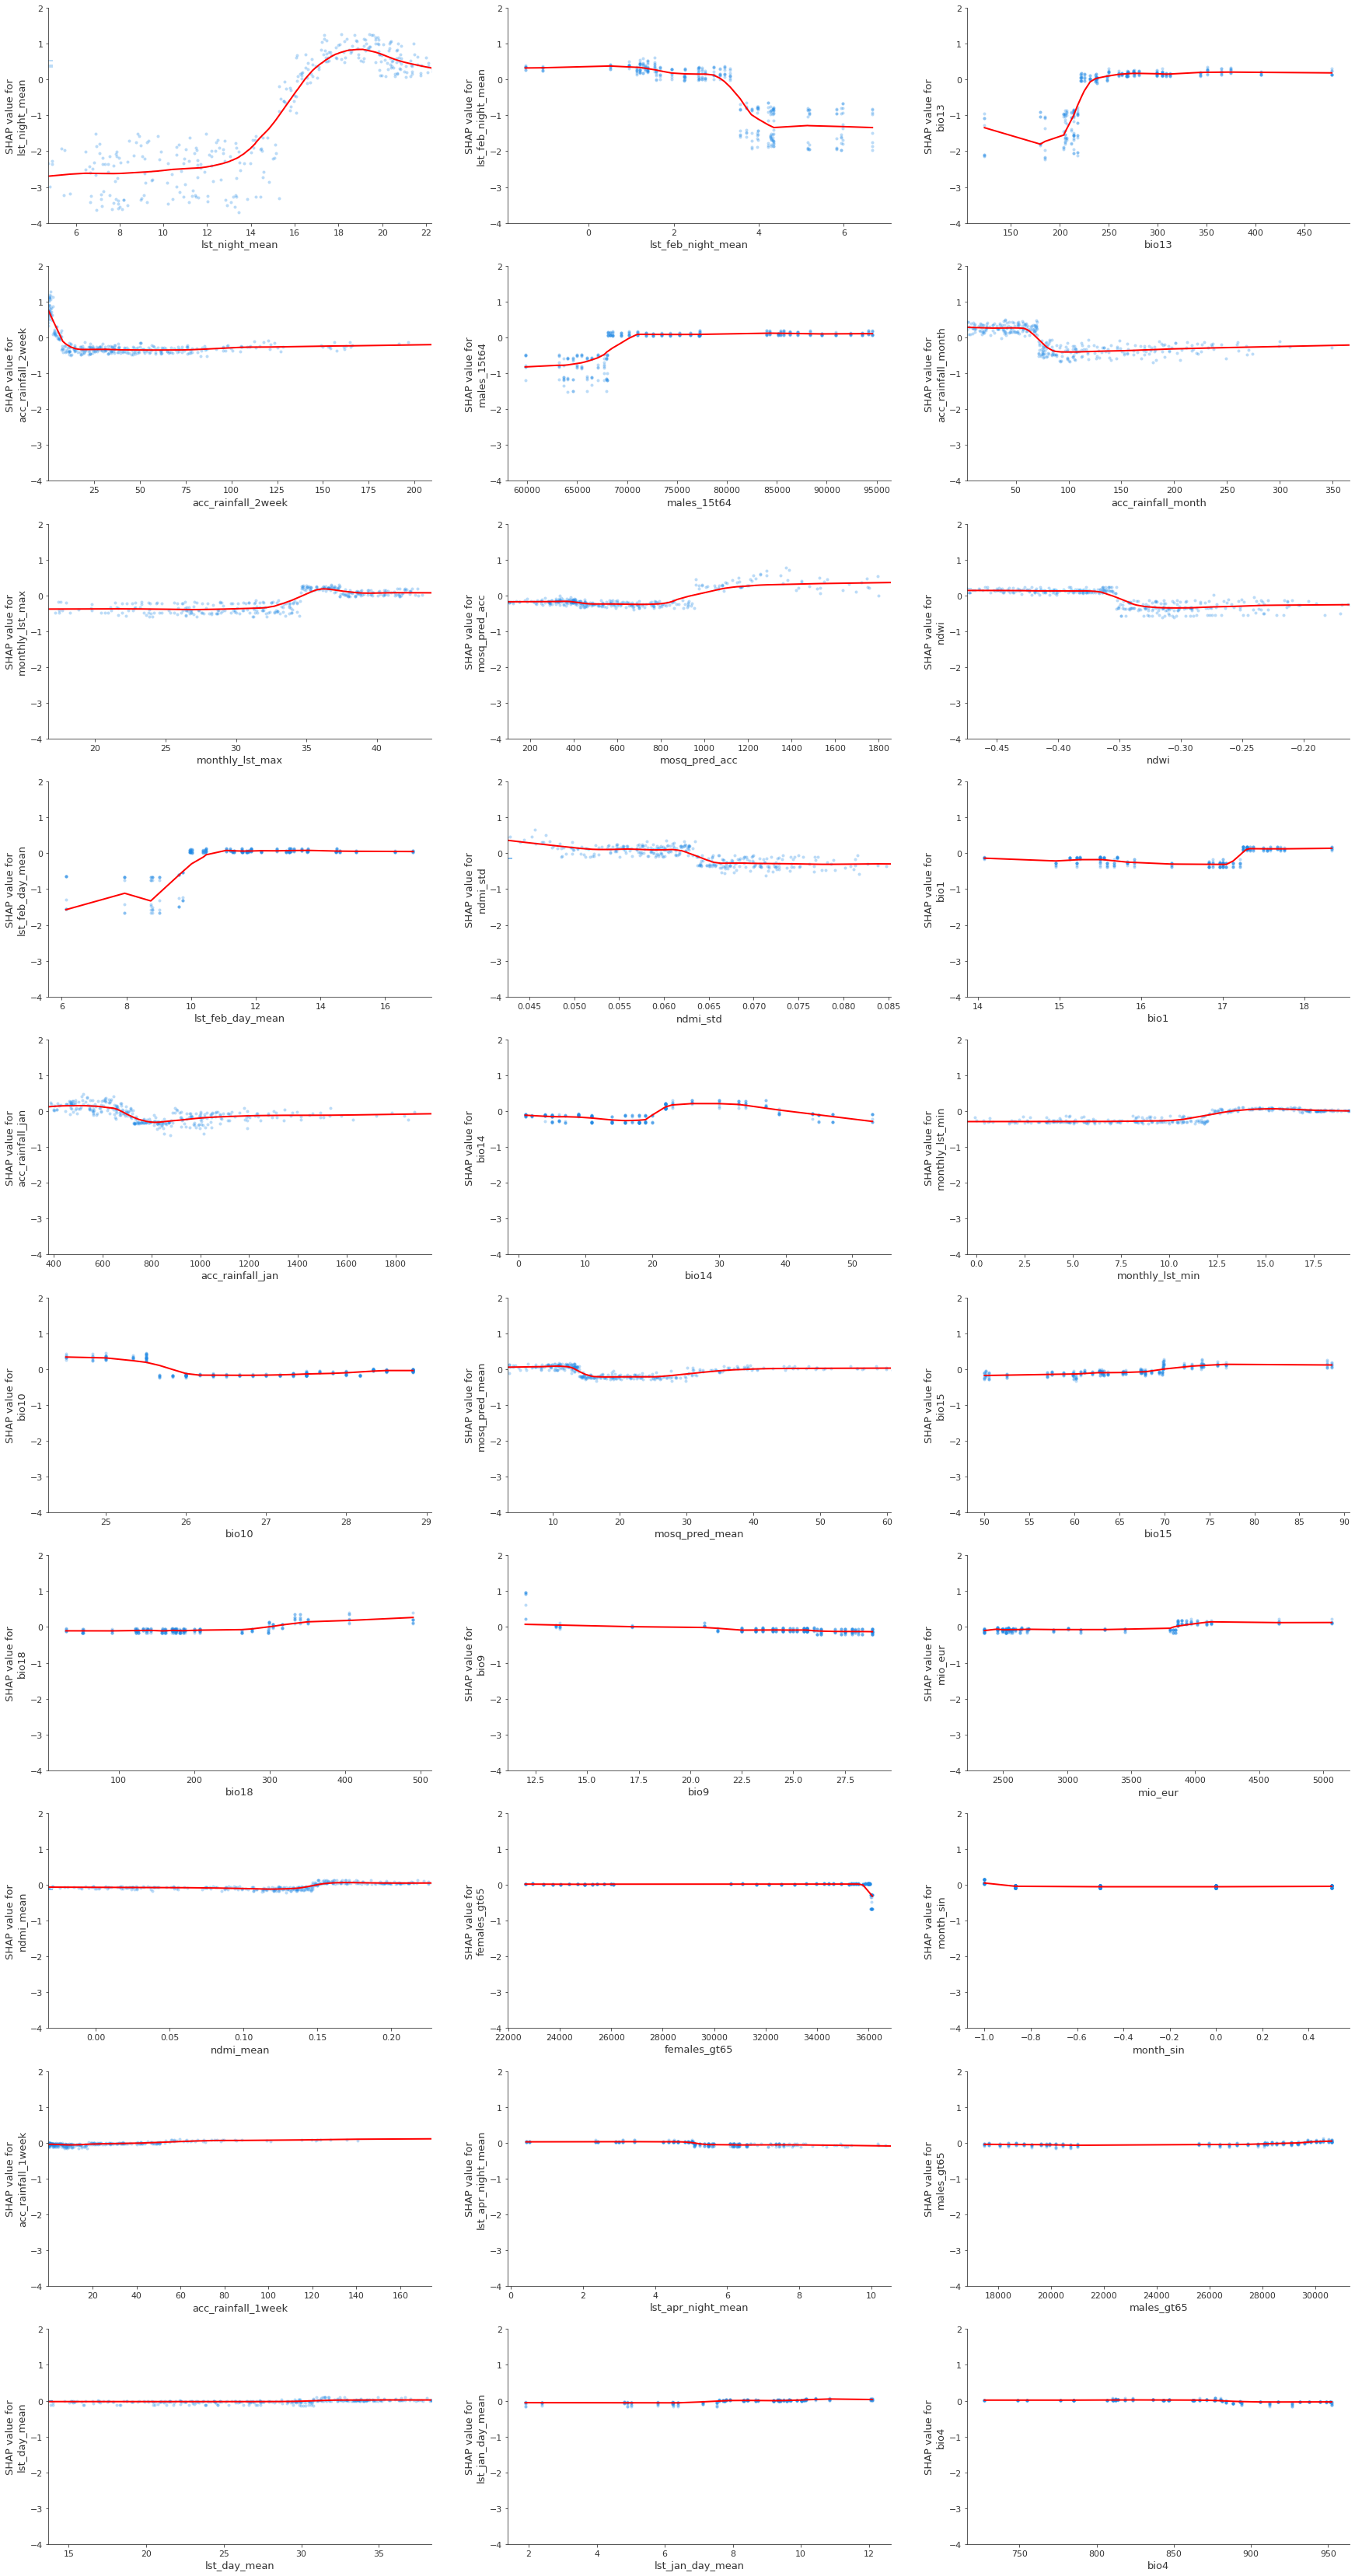

In [81]:
num_plots = 30

fig, axes = plt.subplots(10, 3, figsize=(30, 60))  # Adjust figsize as needed
i = 0

for ft in sorted_mean_abs_values_idx[:num_plots]:
    row = i // 3
    col = i % 3

    ax = axes[row, col]
    feature = ft
    shap_values = tree_shap_values.values
    data = X_train
    feature_names = X_train.columns

    idx = np.where(X_train.columns==feature)[0][0]
    x = X_train.iloc[:,idx]
    y_sv = shap_values[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=2, frac=.3)
    
    ax.plot(*list(zip(*lowess)), color="red", lw=2)
    ax.set_ylim(shap_lim)

    # for tick in ax.get_xticklabels():
    #     tick.set_rotation(60)
    
    shap.dependence_plot(ind=feature, shap_values=shap_values, features=X_train, 
                         feature_names=feature_names, interaction_index=None, 
                         xmin="percentile(1)", xmax="percentile(99)", alpha=0.3, ax=ax, show = False)
    
    i = i+1

plt.show()

    

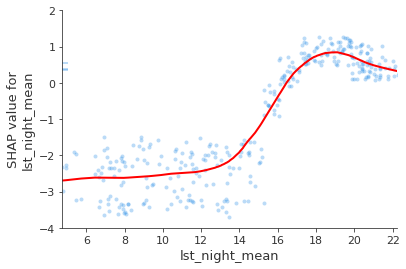

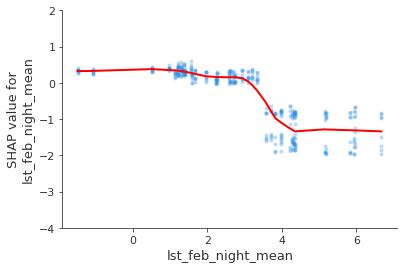

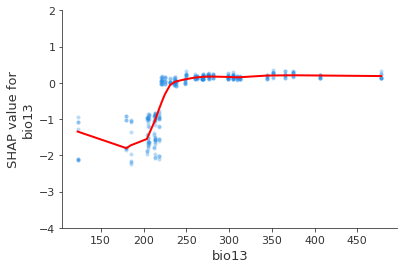

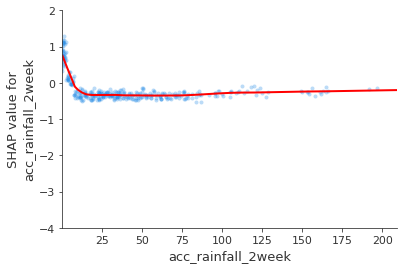

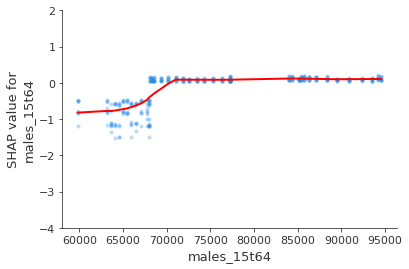

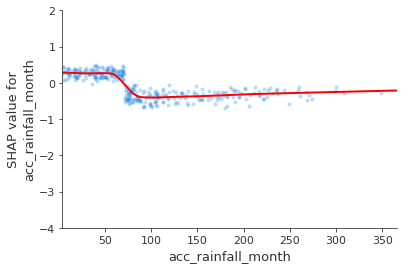

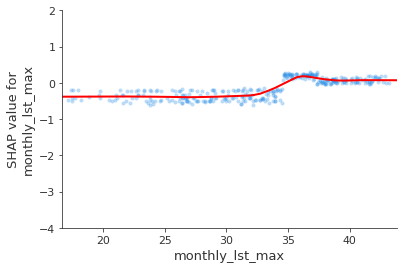

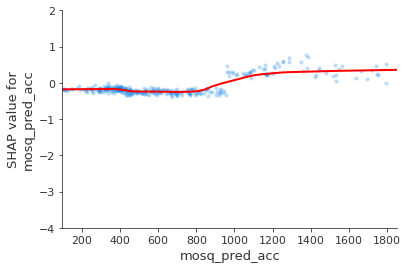

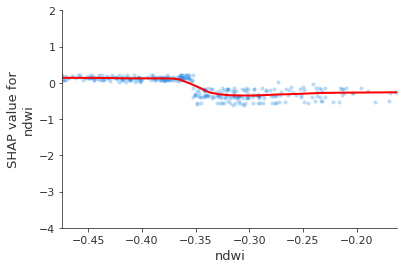

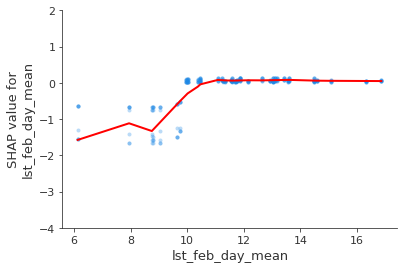

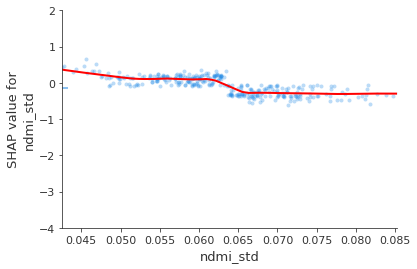

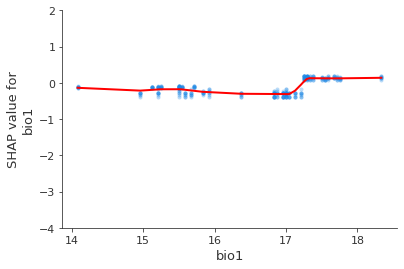

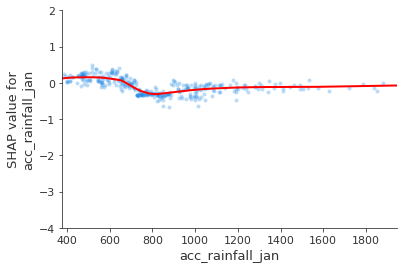

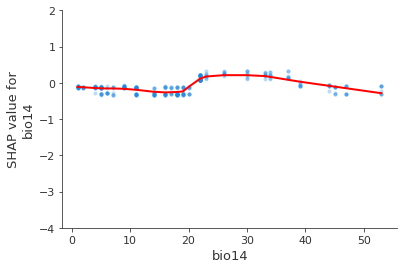

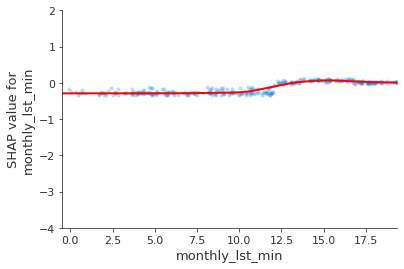

In [82]:
for ft in sorted_mean_abs_values_idx[:15]:
    feature = ft
    shap_values = tree_shap_values.values
    data = X_train
    feature_names = X_train.columns

    idx = np.where(X_train.columns==feature)[0][0]
    x = X_train.iloc[:,idx]
    y_sv = shap_values[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=2,frac=.3)
    _,ax = plt.subplots()
    ax.plot(*list(zip(*lowess)), color="red", lw = 2)
    ax.set_ylim(shap_lim)
    
    shap.dependence_plot(ind = feature, shap_values = shap_values, features = X_train, feature_names = feature_names, 
                         interaction_index=None, xmin="percentile(1)", xmax="percentile(99)", alpha=0.3, ax = ax)